In [ ]:
import os
from pathlib import Path

# Data handling and spatial array manipulation
import xarray as xr
import pandas as pd
import numpy as np

# In-process SQL database management system for spatial querying
import duckdb

# Visualization
import matplotlib.pyplot as plt

# Print versions to ensure smooth environment setup
print(f"xarray version: {xr.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"duckdb version: {duckdb.__version__}")

In [4]:
# Define file path using pathlib for cross-platform compatibility
data_dir = Path(".")
nc_file_name = "S5P_OFFL_L2__CH4____2024.nc" # Replace with your exact filename
file_path = data_dir / nc_file_name

# Verify file existence before opening
if not file_path.exists():
    raise FileNotFoundError(f"The file {file_path} was not found in the directory.")

# Open Sentinel-5P NetCDF dataset focusing on the main 'PRODUCT' group
ds = xr.open_dataset(file_path, group="PRODUCT")

# Display dataset summary
print("--- Sentinel-5P Product Group Summary ---")
print(ds)

--- Sentinel-5P Product Group Summary ---
<xarray.Dataset> Size: 22MB
Dimensions:                              (time: 1, scanline: 4173,
                                          ground_pixel: 215, corner: 4,
                                          layer: 12, level: 13)
Coordinates:
  * time                                 (time) datetime64[ns] 8B 2024-05-30
  * scanline                             (scanline) float64 33kB 0.0 ... 4.17...
  * ground_pixel                         (ground_pixel) float64 2kB 0.0 ... 2...
    latitude                             (time, scanline, ground_pixel) float32 4MB ...
    longitude                            (time, scanline, ground_pixel) float32 4MB ...
  * corner                               (corner) float64 32B 0.0 1.0 2.0 3.0
  * layer                                (layer) float64 96B 0.0 1.0 ... 11.0
  * level                                (level) float64 104B 0.0 1.0 ... 12.0
Data variables:
    delta_time                           (time, 

In [5]:
# 1. Load the dataset
ds = xr.open_dataset(file_path, group="PRODUCT")

# 2. Extract raw arrays
lats = ds["latitude"].values.flatten()
lons = ds["longitude"].values.flatten()
methane = ds["methane_mixing_ratio"].values.flatten()

# 3. Filter out missing values (NaN)
valid_mask = ~np.isnan(methane)

# 4. Create a clean Pandas DataFrame with valid spatial data
df = pd.DataFrame({
    "latitude": lats[valid_mask],
    "longitude": lons[valid_mask],
    "methane_ppb": methane[valid_mask]
})

print("--- Data Extraction Successful ---")
print(f"Total valid methane data points: {len(df)}")
print(df.head())

--- Data Extraction Successful ---
Total valid methane data points: 6644
    latitude   longitude  methane_ppb
0  19.839678 -157.577255  1893.734741
1  19.879581 -157.866333  1886.951050
2  19.894447 -157.800095  1896.307495
3  19.928831 -157.878433  1900.115112
4  19.943699 -157.812164  1909.329102


In [6]:
# 1. Connect to an in-memory DuckDB database
con = duckdb.connect(database=":memory:")

# 2. Register the Pandas DataFrame as a DuckDB virtual table
con.register("methane_data", df)

# 3. SQL Query: Calculate summary statistics and detect high concentration anomalies
query = """
WITH stats AS (
    SELECT 
        AVG(methane_ppb) AS avg_methane,
        STDDEV(methane_ppb) AS std_methane,
        MAX(methane_ppb) AS max_methane,
        MIN(methane_ppb) AS min_methane,
        COUNT(*) AS total_points
    FROM methane_data
)
SELECT 
    ROUND(avg_methane, 2) AS baseline_ppb,
    ROUND(std_methane, 2) AS std_dev_ppb,
    ROUND(max_methane, 2) AS max_ppb,
    ROUND(avg_methane + (2 * std_methane), 2) AS anomaly_threshold_ppb,
    total_points
FROM stats;
"""

# Execute query and fetch results as Pandas DataFrame
summary_df = con.execute(query).df()

print("--- DuckDB Spatial & Baseline Analysis ---")
print(summary_df)

--- DuckDB Spatial & Baseline Analysis ---
   baseline_ppb  std_dev_ppb      max_ppb  anomaly_threshold_ppb  total_points
0        1867.4        30.81  2004.560059                1929.02          6644


Total anomaly points detected: 7


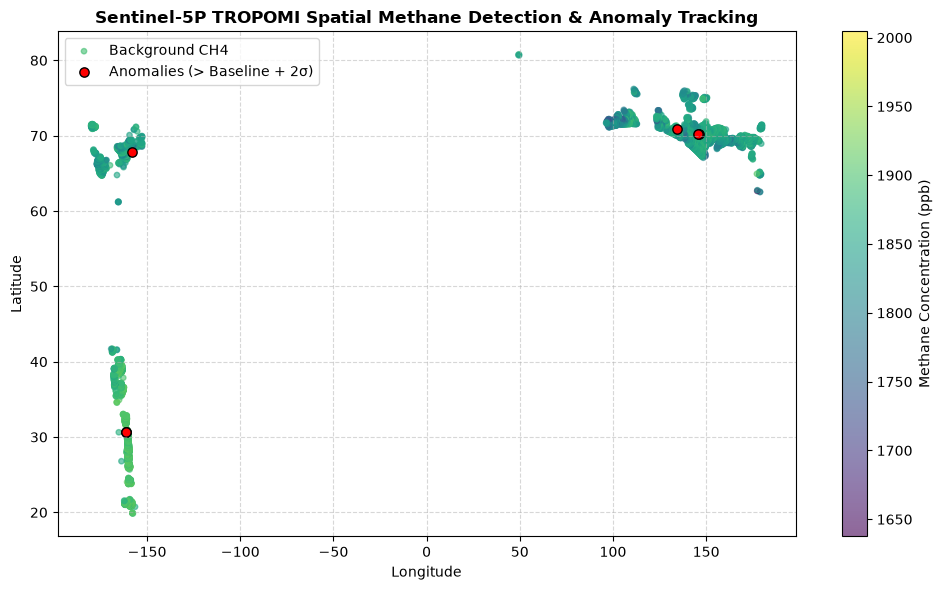

In [7]:
# 1. SQL Query: Extract high methane anomalies (> Baseline + 2*StdDev)
anomaly_query = """
SELECT 
    latitude, 
    longitude, 
    methane_ppb
FROM methane_data
WHERE methane_ppb > 1929.02
ORDER BY methane_ppb DESC;
"""

anomalies_df = con.execute(anomaly_query).df()
print(f"Total anomaly points detected: {len(anomalies_df)}")

# 2. Visualization using Matplotlib
plt.figure(figsize=(10, 6))

# Plot all background data points
scatter_bg = plt.scatter(
    df["longitude"], 
    df["latitude"], 
    c=df["methane_ppb"], 
    cmap="viridis", 
    alpha=0.6, 
    s=15,
    label="Background CH4"
)
cbar = plt.colorbar(scatter_bg)
cbar.set_label("Methane Concentration (ppb)")

# Highlight statistical anomalies (> 2 sigma)
plt.scatter(
    anomalies_df["longitude"], 
    anomalies_df["latitude"], 
    color="red", 
    edgecolor="black", 
    s=45, 
    label="Anomalies (> Baseline + 2σ)"
)

# Formatting plot
plt.title("Sentinel-5P TROPOMI Spatial Methane Detection & Anomaly Tracking", fontsize=12, fontweight="bold")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()